In [65]:
import pandas as pd
import utils
import matplotlib.pyplot as plt


In [60]:
# PREGUTNAR SI PUEDO USAR urllib en vez de wget

data_path = "netflix_titles.csv"

# utils.mostrar_archivo(data_path)

df = pd.read_csv(data_path)

# df.info() # usar este, y no el otro, que aparentemente es de la catedra (PREGUNTAR)
#df.columns.tolist()

# df.head() #df[0:5]

display(df.describe(include='all')) # no falta ninguna porque pongo 'all' que incluye las cualitativas.
# es con include

analisis_de_datos = '''
 show_id: Cuantitativa nominal - Identificador unico de la serie
     Las ids siempre deberian ser eliminadas ya que son todas unique ? PREGUNTAR.
     cada ID es una etiqueta única asignada a una observación para diferenciarla de las demás
     no es cuantitativa porque carece de propiedades matemáticas 
 type: Cualitativa nominal dicotomica - Tipo de contenido: Serie de tv, pelicula
 title: Cualitativa nominal - 
 director: Cualitativa nominal -
 cast: Cualitativa nominal - Listado de actores
 country: Cualitativa nominal -
 date_added: Cualitativa ordinal
 release_year: Cuantitativa discreta
 rating: Cualitativa ordinal
     PREGUNTAR
 duration: Cuantitativa discreta
 listed_in: Cualitativa nominal - Categorias
 description: Cualitativa nominal
'''

# df[df['type'] == 'Movie'].describe(include='all')
# con esto vemos que rajiv es el que tiene mas pelis

# df.count()

# display("cantidad de series", (df.count()- df[df['type'] == 'Movie'].count()).show_id)
# display("cantidad de pelis", df - df[df['type'] != 'Movie'])
# print(len(df[df['type'] == 'Movie']))

# df['release_year'].describe() # tambien se puede hacer .min()

# df['title','release_year'].min()

# df.min('release_year')

df.sort_values(by="release_year", ascending=True).head(1)
df[df['release_year'] == df['release_year'].min()]


df[df['country'] == 'United States'].describe
df[df['country']=='United States'].shape[0] #(0: filas, 1: columnas)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8809,8809,8809,6175,7984,7978,8799,8809.000000,8805,8806,8809,8809
unique,8809,2,8806,4529,7694,748,1768,NaN,18,220,516,8777
top,s8809,Movie,22-Jul,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6132,2,19,19,2819,109,NaN,3208,1794,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.181292,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.818932,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


2819

In [ ]:
# acomodar csv by tomi

#cargamos el archivo especificando encoding latin-1
df = pd.read_csv("netflix_titles.csv", encoding="latin-1")

#eliminamos las columnas 'Unnamed' vacias generadas por comas
columnas_validas = [col for col in df.columns if not col.startswith("Unnamed")]
df = df[columnas_validas]

#cambiamos a UTF-8
df.to_csv("netflix_titles.csv", index=False, encoding="utf-8")

print(df)

In [62]:
import sweetviz as sv

repo = sv.analyze(df)

repo.show_html("reporte_obesidad.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report reporte_obesidad.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [63]:
repo.show_html("reporte_netflix.html")

Report reporte_obesidad.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


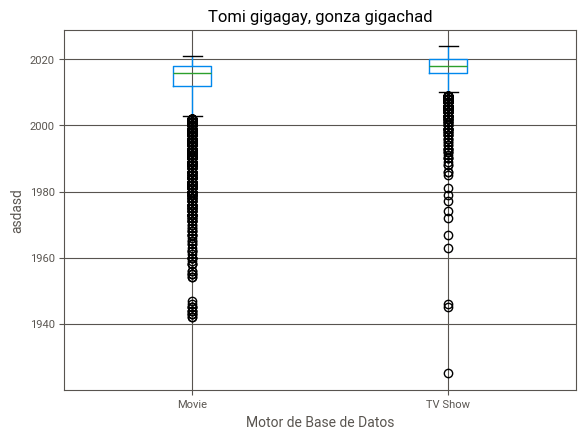

In [66]:
# spearman cuali X cuanti
# chi2 cuali X cuali
# pierson cuanti X cuanti

df.boxplot(column='release_year', by='type')

plt.title('Tomi , gonza ')
plt.suptitle('') # Esto elimina el título automático feo que pone Pandas
plt.ylabel('asdasd')
plt.xlabel('Motor de Base de Datos')

plt.show()

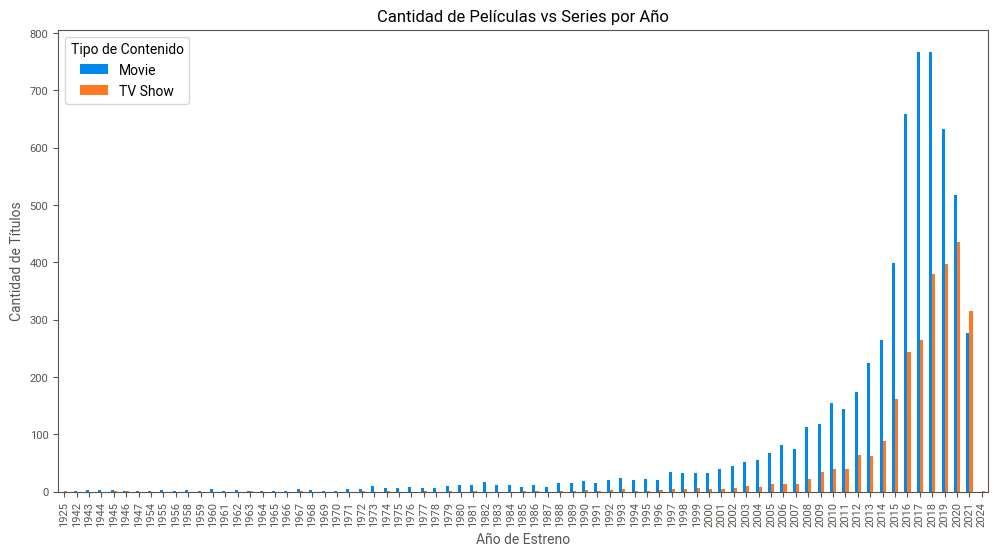

In [69]:

conteo_por_año = df.groupby(['release_year', 'type']).size().unstack()


conteo_por_año.plot(kind='bar', figsize=(12, 6))

plt.title('Cantidad de Películas vs Series por Año')
plt.xlabel('Año de Estreno')
plt.ylabel('Cantidad de Títulos')
plt.legend(title='Tipo de Contenido')

plt.show()

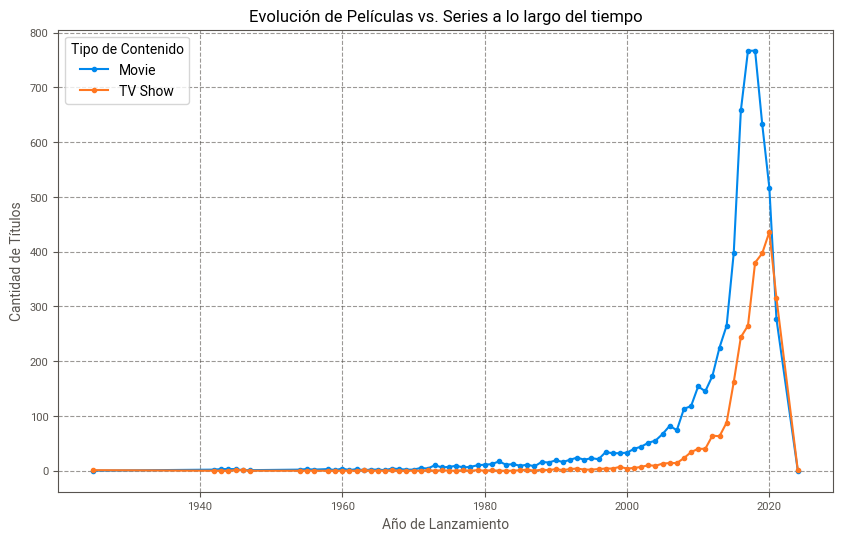

In [70]:
import matplotlib.pyplot as plt

# 1. Agrupamiento temporal y cálculo de frecuencias
# Agrupamos por año y contamos cuántos títulos hay de cada tipo
conteo_anual = df.groupby('release_year')['type'].value_counts()

# 2. Reestructuración de los datos
# unstack() separa los tipos ('Movie' y 'TV Show') en columnas distintas para poder graficar dos líneas.
# fillna(0) reemplaza con cero los años donde solo hubo un tipo de contenido y no el otro.
tendencia = conteo_anual.unstack().fillna(0)

# 3. Visualización de tendencias (Cantidades absolutas)
# Generamos el gráfico de líneas
tendencia.plot(kind='line', figsize=(10, 6), marker='o')

# Configuramos los detalles estéticos del gráfico con matplotlib
plt.title('Evolución de Películas vs. Series a lo largo del tiempo')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Títulos')
plt.grid(True, linestyle='--', alpha=0.6) # Agrega una cuadrícula para facilitar la lectura
plt.legend(title='Tipo de Contenido')

# Mostramos el gráfico en pantalla
plt.show()

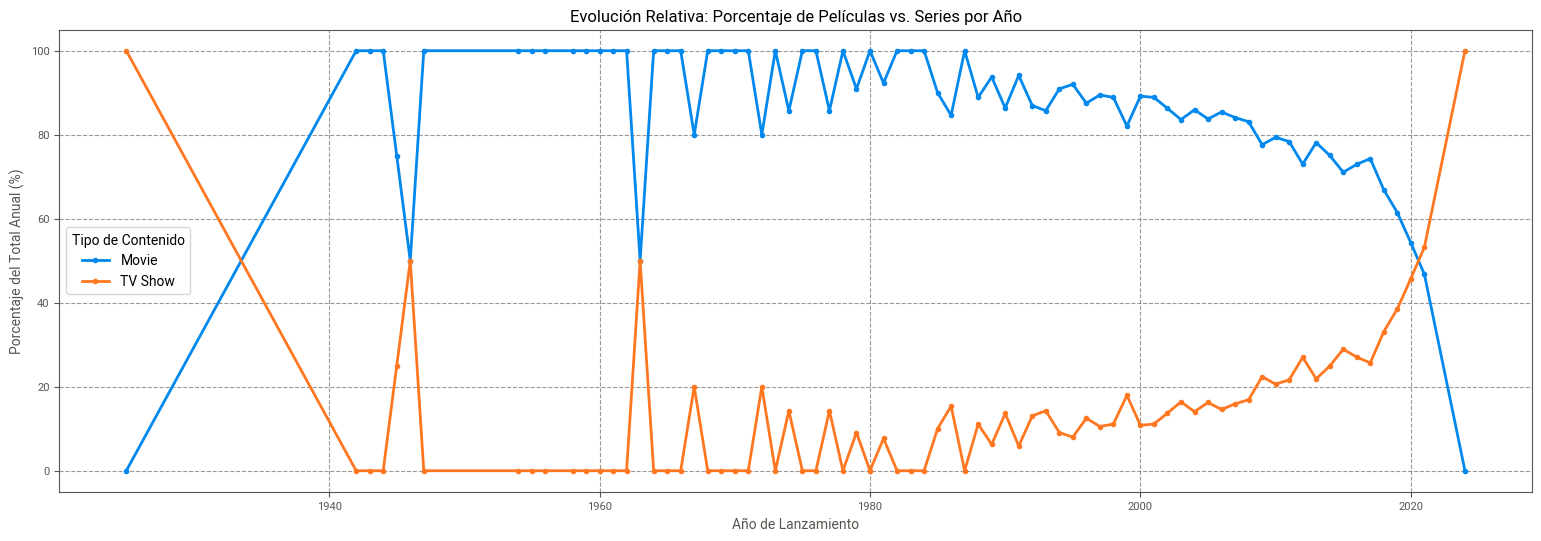

In [75]:
import matplotlib.pyplot as plt

# 1. Agrupamiento y armado de la tabla base
conteo_anual = df.groupby('release_year')['type'].value_counts()
tendencia = conteo_anual.unstack().fillna(0)

# 2. Cálculo de la relación porcentual (La clave de tu análisis)
# Suma el total de lanzamientos por año y divide cada tipo por ese total
proporcion_anual = tendencia.div(tendencia.sum(axis=1), axis=0) * 100

# 3. Generación del gráfico de líneas temporales
proporcion_anual.plot(kind='line', figsize=(10, 6), marker='o', linewidth=2)

# Configuraciones estéticas
plt.title('Evolución Relativa: Porcentaje de Películas vs. Series por Año')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Porcentaje del Total Anual (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Tipo de Contenido')

plt.show()

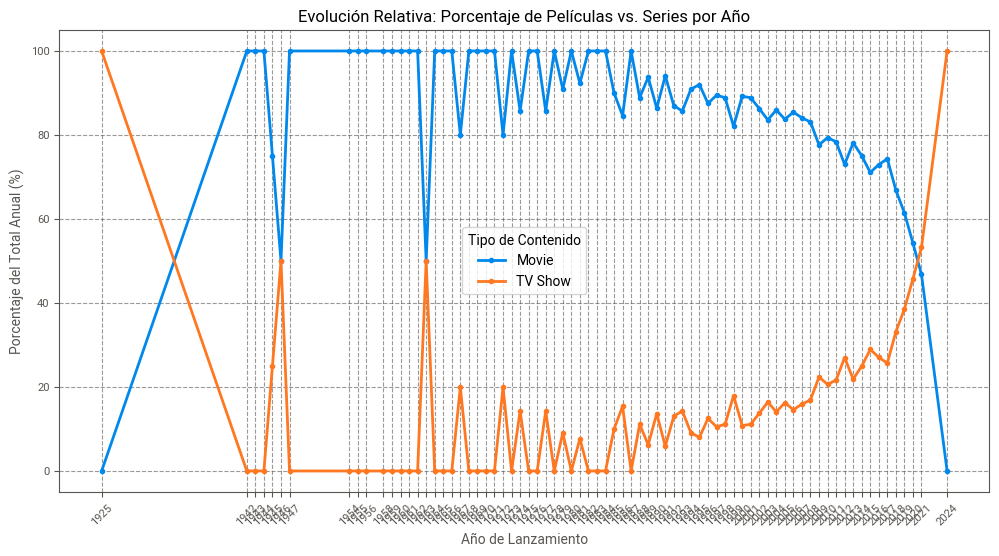

In [76]:
import matplotlib.pyplot as plt

# 1. Agrupamiento y armado de la tabla base
conteo_anual = df.groupby('release_year')['type'].value_counts()
tendencia = conteo_anual.unstack().fillna(0)

# 2. Cálculo de la relación porcentual 
proporcion_anual = tendencia.div(tendencia.sum(axis=1), axis=0) * 100

# 3. Generación del gráfico de líneas temporales
# (Agrandamos un poco el figsize a 12, 6 para que entren mejor los años)
proporcion_anual.plot(kind='line', figsize=(12, 6), marker='o', linewidth=2)

# Configuraciones estéticas
plt.title('Evolución Relativa: Porcentaje de Películas vs. Series por Año')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Porcentaje del Total Anual (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Tipo de Contenido')

# --- NUEVO: Ajuste de los puntos en el eje X ---
# Extraemos todos los años presentes en el índice
anios = proporcion_anual.index

# Forzamos a que el gráfico ponga una marca por cada año disponible
# Usamos rotation=45 para inclinar los textos y que no se superpongan visualmente
plt.xticks(anios, rotation=45) 

plt.show()